# Ablation Study — Results Explorer

Visualises the ablation results stored in `ablation_results_all.csv`.

**Metrics**
| Metric | Meaning | Direction |
|--------|---------|-----------|
| NMI | Normalised Mutual Information (cluster ↔ label) | ↑ better |
| AMI | Adjusted Mutual Information | ↑ better |
| Purity | Cluster purity | ↑ better |
| MAE_Age | Mean absolute error on age prediction | ↓ better |
| AUC_Sex | AUROC for sex prediction | ↑ better |

Rows whose run crashed are retained in the CSV with empty metric columns — they are dropped automatically.

In [1]:
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from matplotlib.colors import Normalize

# ── locate the CSV relative to this notebook ──────────────────────────────
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("ablation_exploration.ipynb"))
CSV_PATH = os.path.join(NOTEBOOK_DIR, "ablation_results_all.csv")

df_raw = pd.read_csv(CSV_PATH)

METRICS = ["NMI", "AMI", "Purity", "MAE_Age", "AUC_Sex"]
# keep only rows that produced at least one metric
df = df_raw[df_raw["NMI"].notna()].copy().reset_index(drop=True)

# lower-is-better flag per metric (used for colouring)
LOWER_IS_BETTER = {"NMI": False, "AMI": False, "Purity": False,
                   "MAE_Age": True, "AUC_Sex": False}

print(f"Total variants: {len(df_raw)}  |  Successful: {len(df)}  |  Failed/errored: {len(df_raw) - len(df)}")
df[["variant"] + METRICS]

Total variants: 48  |  Successful: 48  |  Failed/errored: 0


,variant,NMI,AMI,Purity,MAE_Age,AUC_Sex
0,baseline,0.207935,0.199663,0.537980,7.780194,0.901058
1,no_disentangle,0.197575,0.189184,0.533508,19.599416,0.385229
2,no_age,0.202219,0.193873,0.534880,19.136831,0.901095
3,no_sex,0.212978,0.204703,0.545910,7.657963,0.647658
4,no_temporal,0.177828,0.169250,0.525817,7.732018,0.897825
5,no_record_attn,0.205831,0.197507,0.544181,7.557303,0.897939
6,no_som_commit,0.205346,0.197049,0.528679,7.646821,0.899330
7,no_som_smooth,0.140906,0.132777,0.491772,7.691631,0.893749
8,no_kl,0.000000,0.000000,0.448664,7.710201,0.896243
9,small_latent,0.196449,0.188043,0.537443,7.515630,0.901887


## 1 — Overview: all metrics side-by-side

Horizontal bar chart for every metric.  The baseline is highlighted in orange; all other bars are blue.  For MAE_Age the x-axis is reversed so "better" is always to the right.

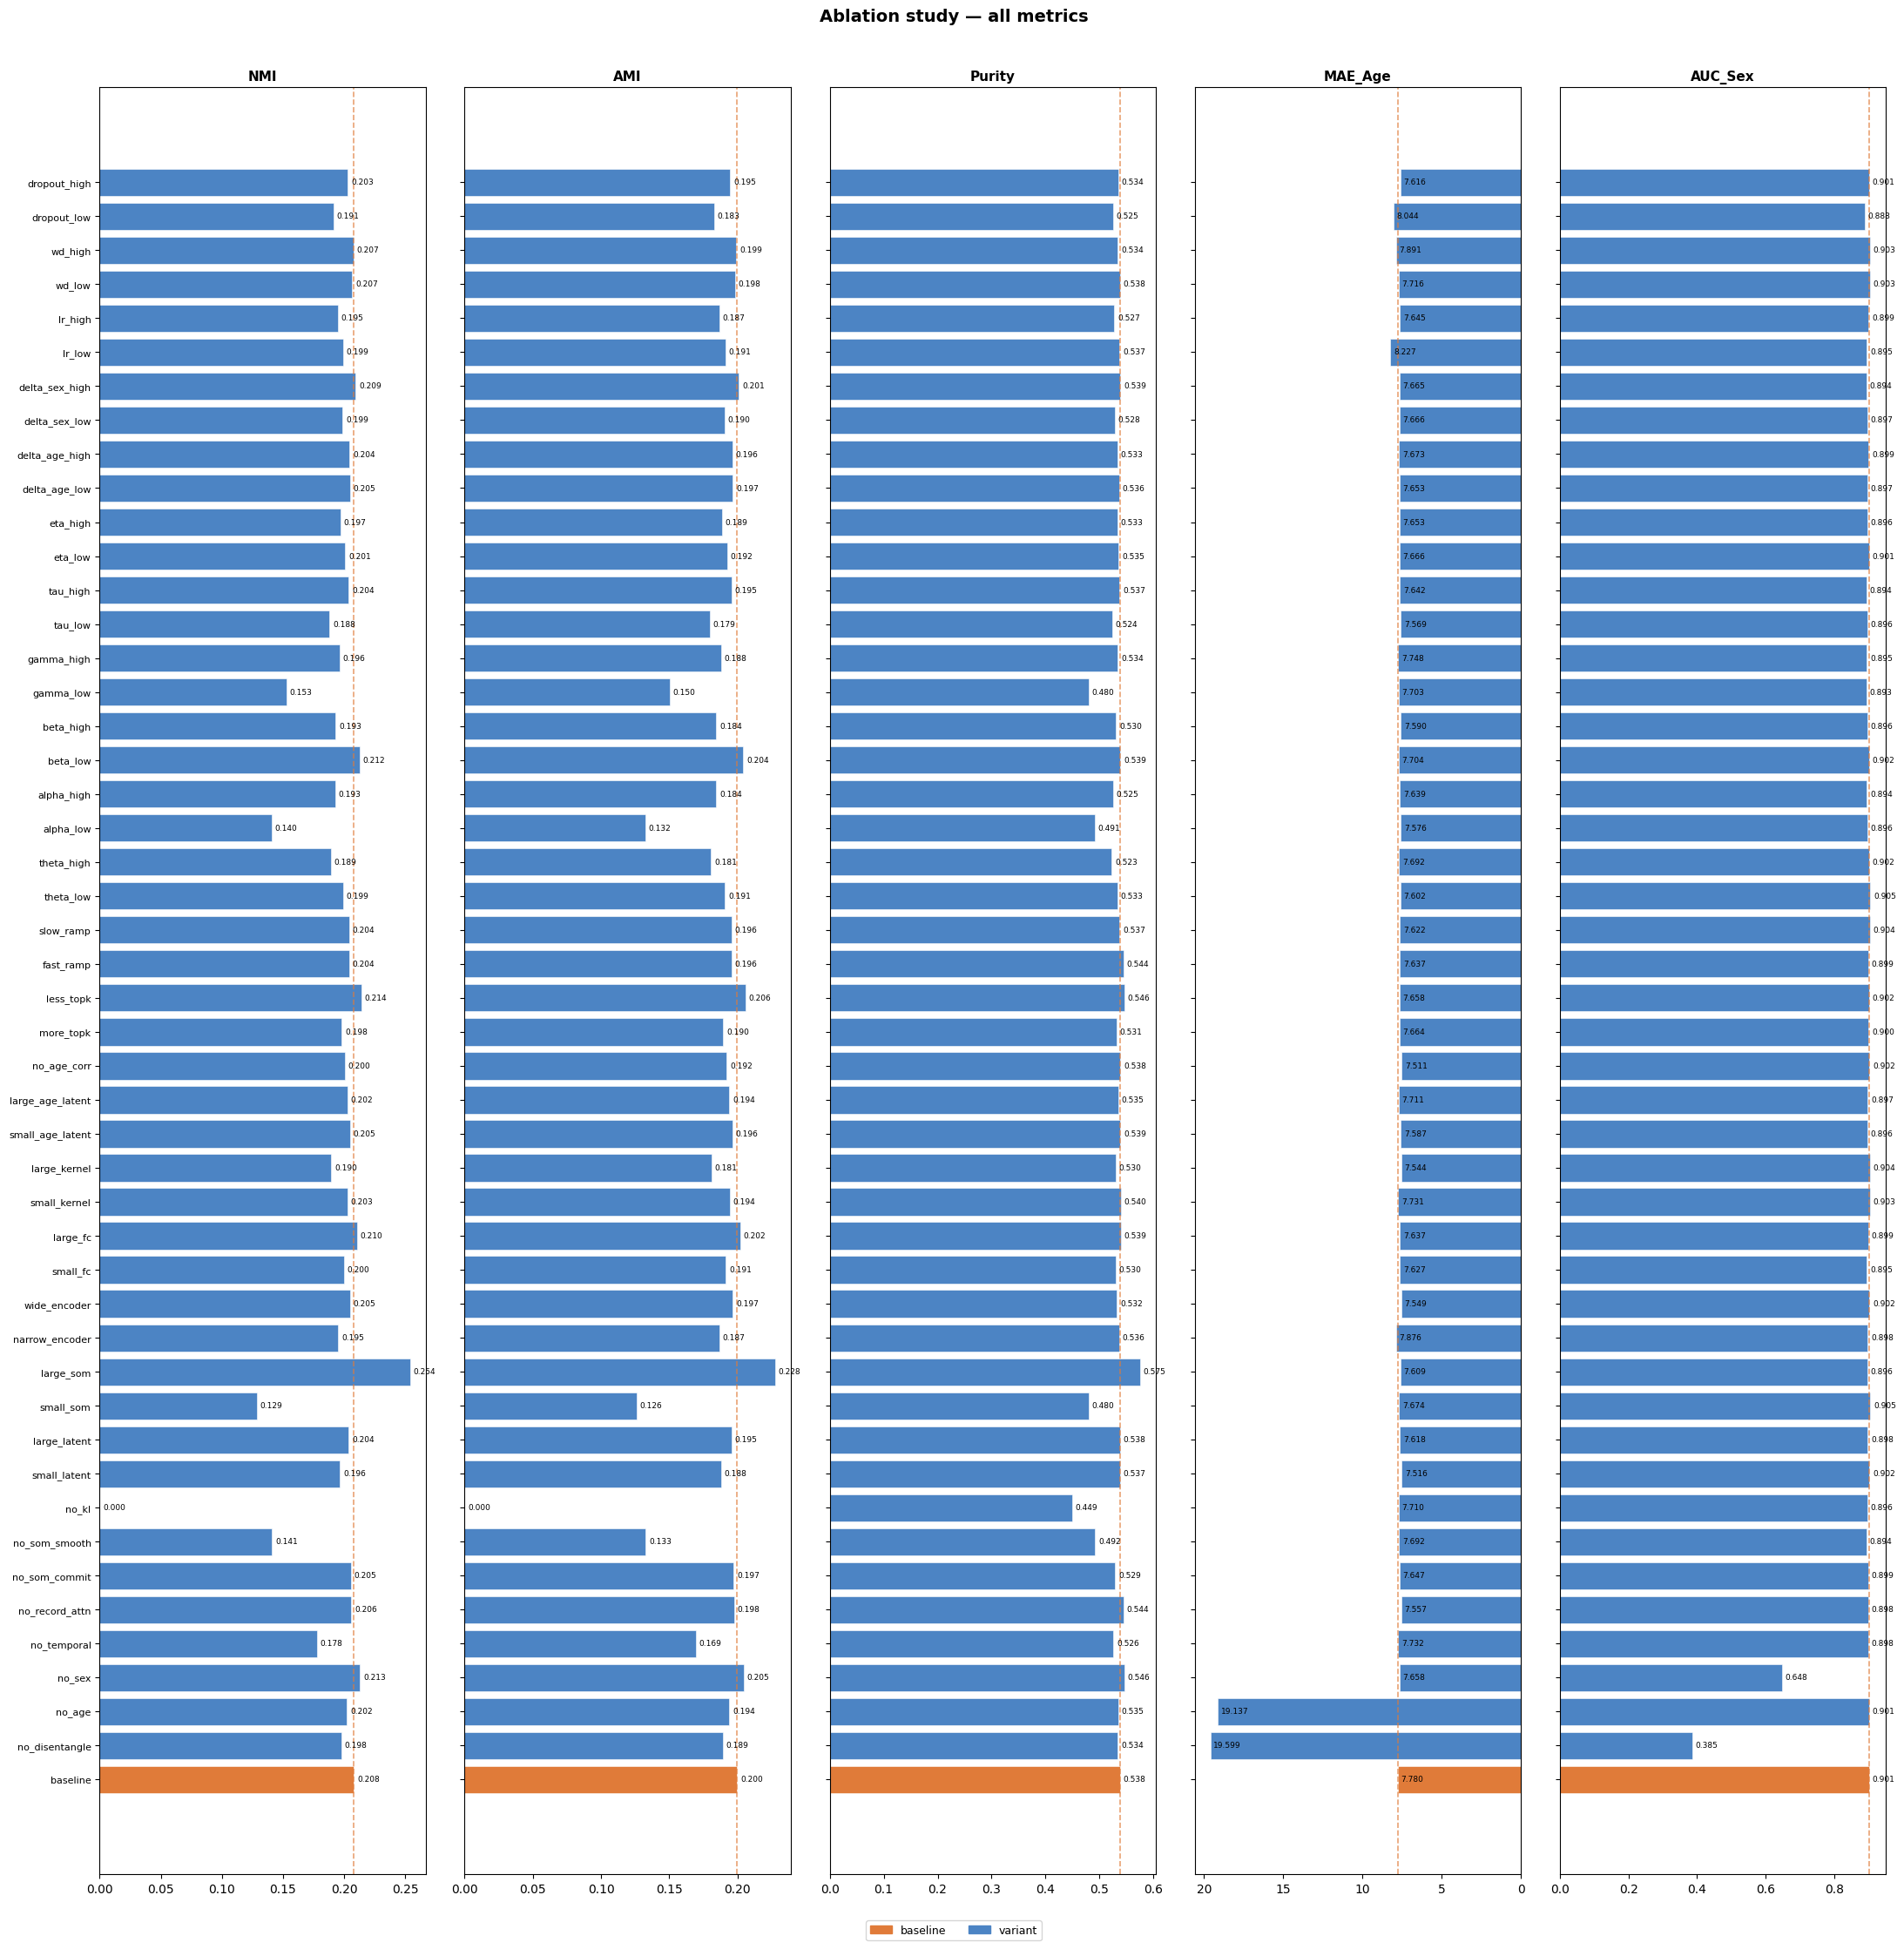

In [2]:
fig, axes = plt.subplots(1, len(METRICS), figsize=(22, max(6, len(df) * 0.45)), sharey=True)

variants = df["variant"].tolist()
colors = ["#E07B39" if v == "baseline" else "#4C84C4" for v in variants]

for ax, metric in zip(axes, METRICS):
    vals = df[metric].values
    bars = ax.barh(variants, vals, color=colors, edgecolor="white", linewidth=0.4)
    ax.set_title(metric, fontweight="bold", fontsize=11)
    ax.axvline(df.loc[df["variant"] == "baseline", metric].values[0],
               color="#E07B39", linewidth=1.2, linestyle="--", alpha=0.7)
    ax.tick_params(axis="y", labelsize=8)
    if LOWER_IS_BETTER[metric]:
        ax.invert_xaxis()
    # annotate bar values
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() + (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", ha="left", fontsize=6.5)

patch_base = mpatches.Patch(color="#E07B39", label="baseline")
patch_var  = mpatches.Patch(color="#4C84C4", label="variant")
fig.legend(handles=[patch_base, patch_var], loc="lower center", ncol=2,
           bbox_to_anchor=(0.5, -0.02), fontsize=9)
fig.suptitle("Ablation study — all metrics", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("ablation_overview.png", dpi=150, bbox_inches="tight")
plt.show()

## 2 — Delta vs. baseline

How much does each variant improve or hurt each metric relative to the baseline?  
Red = degradation, green = improvement (accounting for the MAE_Age direction flip).

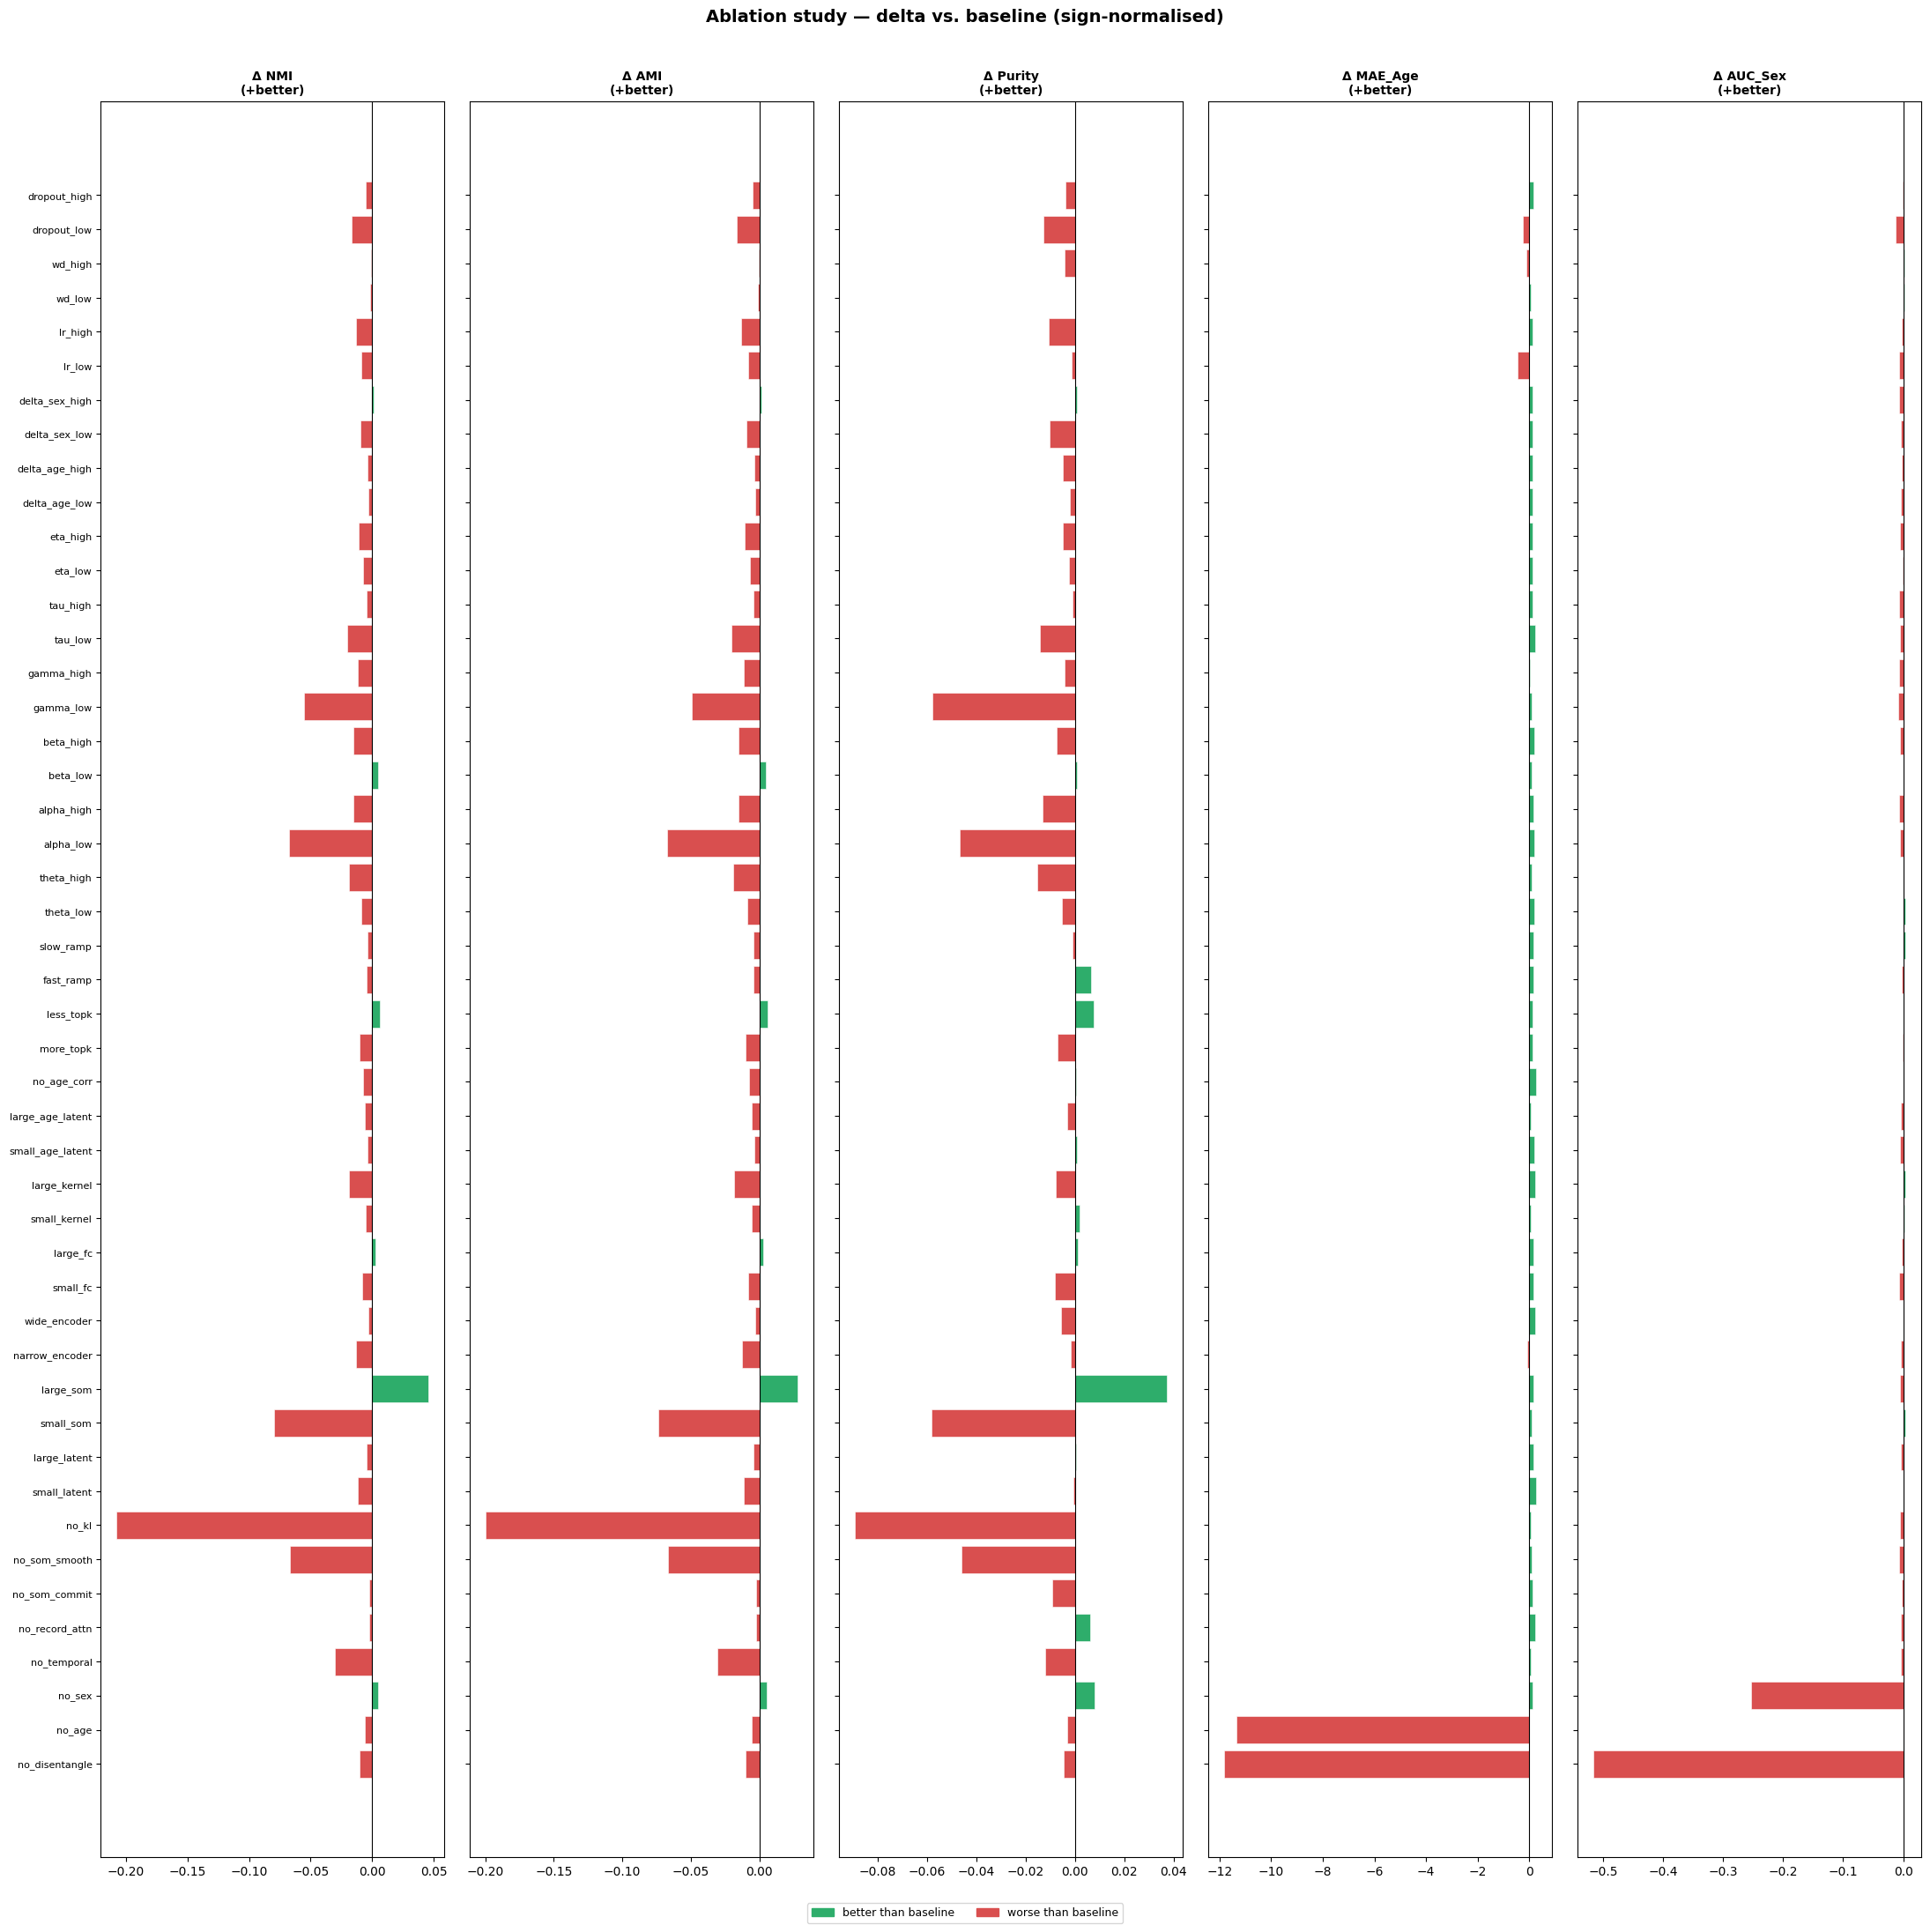

In [3]:
baseline_vals = df.loc[df["variant"] == "baseline", METRICS].iloc[0]
df_delta = df[df["variant"] != "baseline"].copy().reset_index(drop=True)

# for lower-is-better metrics, flip sign so positive always means better
for m in METRICS:
    sign = -1 if LOWER_IS_BETTER[m] else 1
    df_delta[f"delta_{m}"] = sign * (df_delta[m] - baseline_vals[m])

delta_cols = [f"delta_{m}" for m in METRICS]

fig, axes = plt.subplots(1, len(METRICS), figsize=(22, max(5, len(df_delta) * 0.45)), sharey=True)

for ax, metric, dcol in zip(axes, METRICS, delta_cols):
    vals = df_delta[dcol].values
    bar_colors = ["#2EAD6B" if v >= 0 else "#D94F4F" for v in vals]
    ax.barh(df_delta["variant"], vals, color=bar_colors, edgecolor="white", linewidth=0.4)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"Δ {metric}\n(+better)", fontweight="bold", fontsize=10)
    ax.tick_params(axis="y", labelsize=8)

good_patch = mpatches.Patch(color="#2EAD6B", label="better than baseline")
bad_patch  = mpatches.Patch(color="#D94F4F", label="worse than baseline")
fig.legend(handles=[good_patch, bad_patch], loc="lower center", ncol=2,
           bbox_to_anchor=(0.5, -0.02), fontsize=9)
fig.suptitle("Ablation study — delta vs. baseline (sign-normalised)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("ablation_delta.png", dpi=150, bbox_inches="tight")
plt.show()

## 3 — Heatmap: normalised metrics

Each metric is min-max normalised (0 = worst, 1 = best across all variants) so all five columns are comparable on the same colour scale.

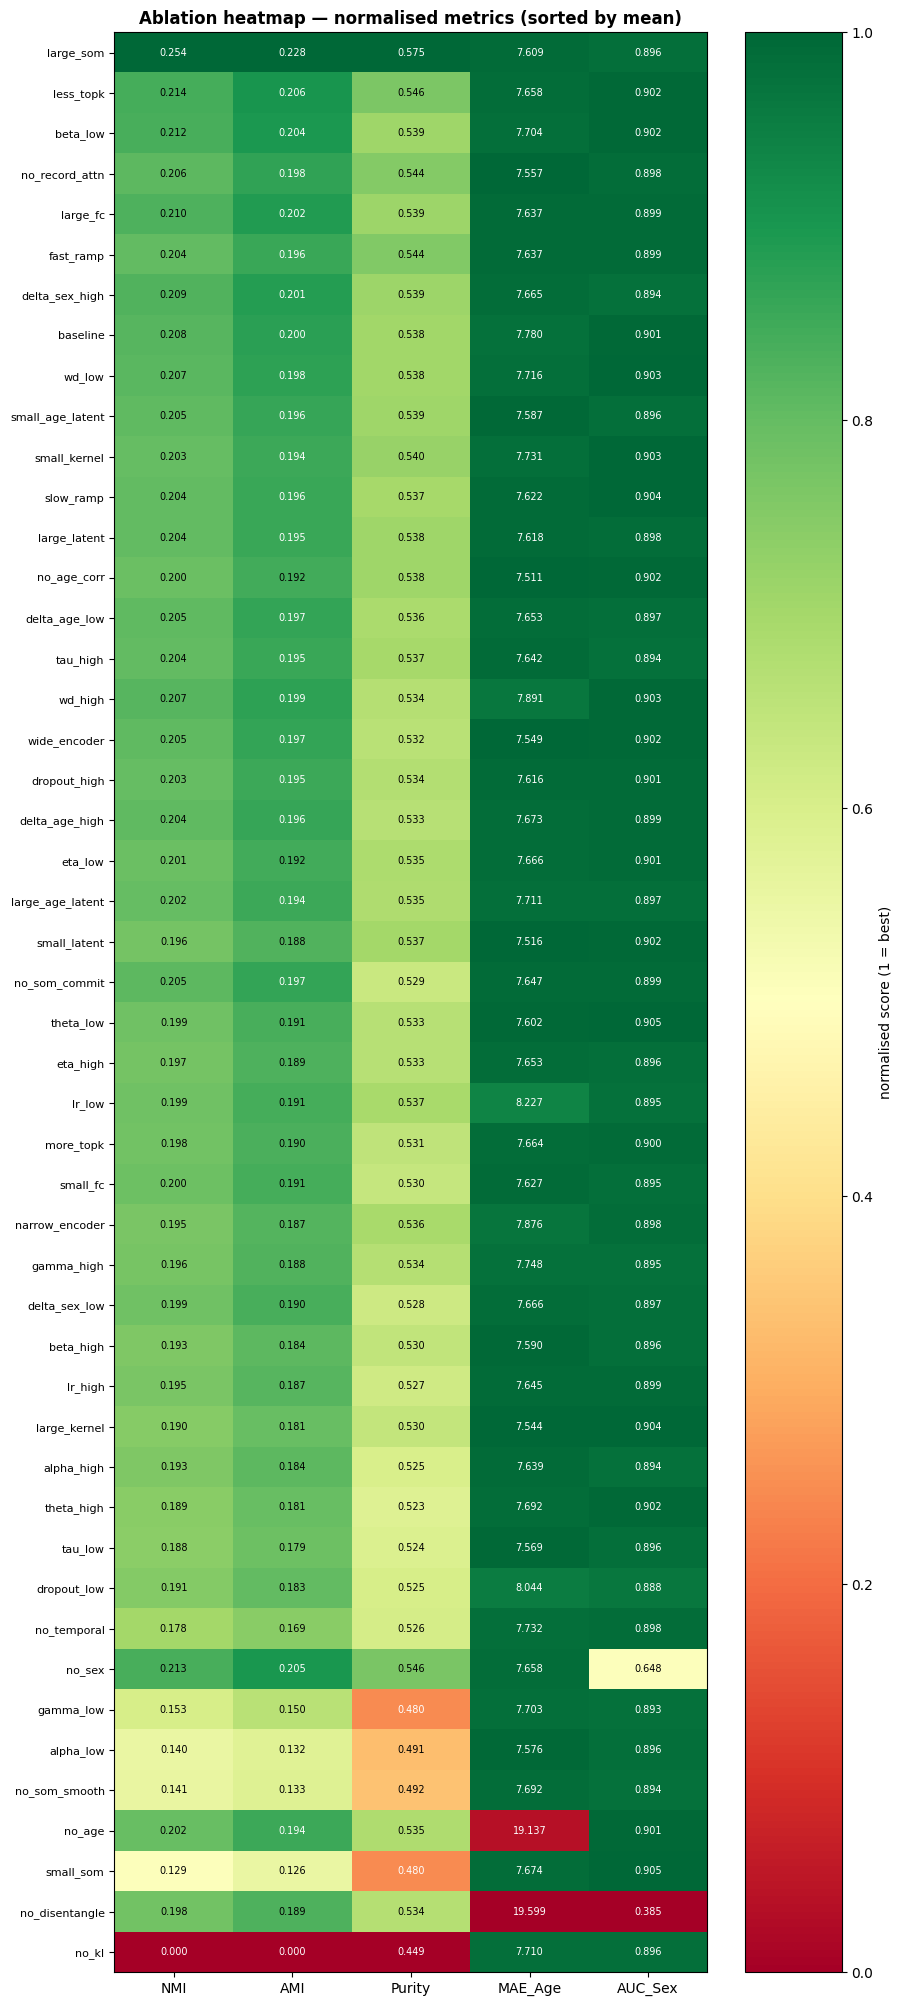

In [4]:
norm_df = df[["variant"] + METRICS].copy().set_index("variant")

# normalise so 1 = best, 0 = worst (flip MAE_Age)
for m in METRICS:
    col = norm_df[m]
    mn, mx = col.min(), col.max()
    if mx == mn:
        norm_df[m] = 0.5
    elif LOWER_IS_BETTER[m]:
        norm_df[m] = 1 - (col - mn) / (mx - mn)
    else:
        norm_df[m] = (col - mn) / (mx - mn)

# sort rows by mean normalised score
norm_df["mean"] = norm_df.mean(axis=1)
norm_df = norm_df.sort_values("mean", ascending=False)
norm_df = norm_df.drop(columns="mean")

fig, ax = plt.subplots(figsize=(9, max(5, len(norm_df) * 0.42)))
im = ax.imshow(norm_df.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)

ax.set_xticks(range(len(METRICS)))
ax.set_xticklabels(METRICS, fontsize=10)
ax.set_yticks(range(len(norm_df)))
ax.set_yticklabels(norm_df.index, fontsize=8)

# annotate cells
for i in range(len(norm_df)):
    for j, m in enumerate(METRICS):
        raw_val = df.loc[df["variant"] == norm_df.index[i], m].values[0]
        ax.text(j, i, f"{raw_val:.3f}", ha="center", va="center", fontsize=7,
                color="black" if 0.25 < norm_df.values[i, j] < 0.85 else "white")

plt.colorbar(im, ax=ax, label="normalised score (1 = best)")
ax.set_title("Ablation heatmap — normalised metrics (sorted by mean)", fontweight="bold")
plt.tight_layout()
plt.savefig("ablation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 4 — Loss-weight sweeps

For each loss-weight group (theta, alpha, beta, gamma, tau, eta) compare low / baseline / high on a small bar grid.

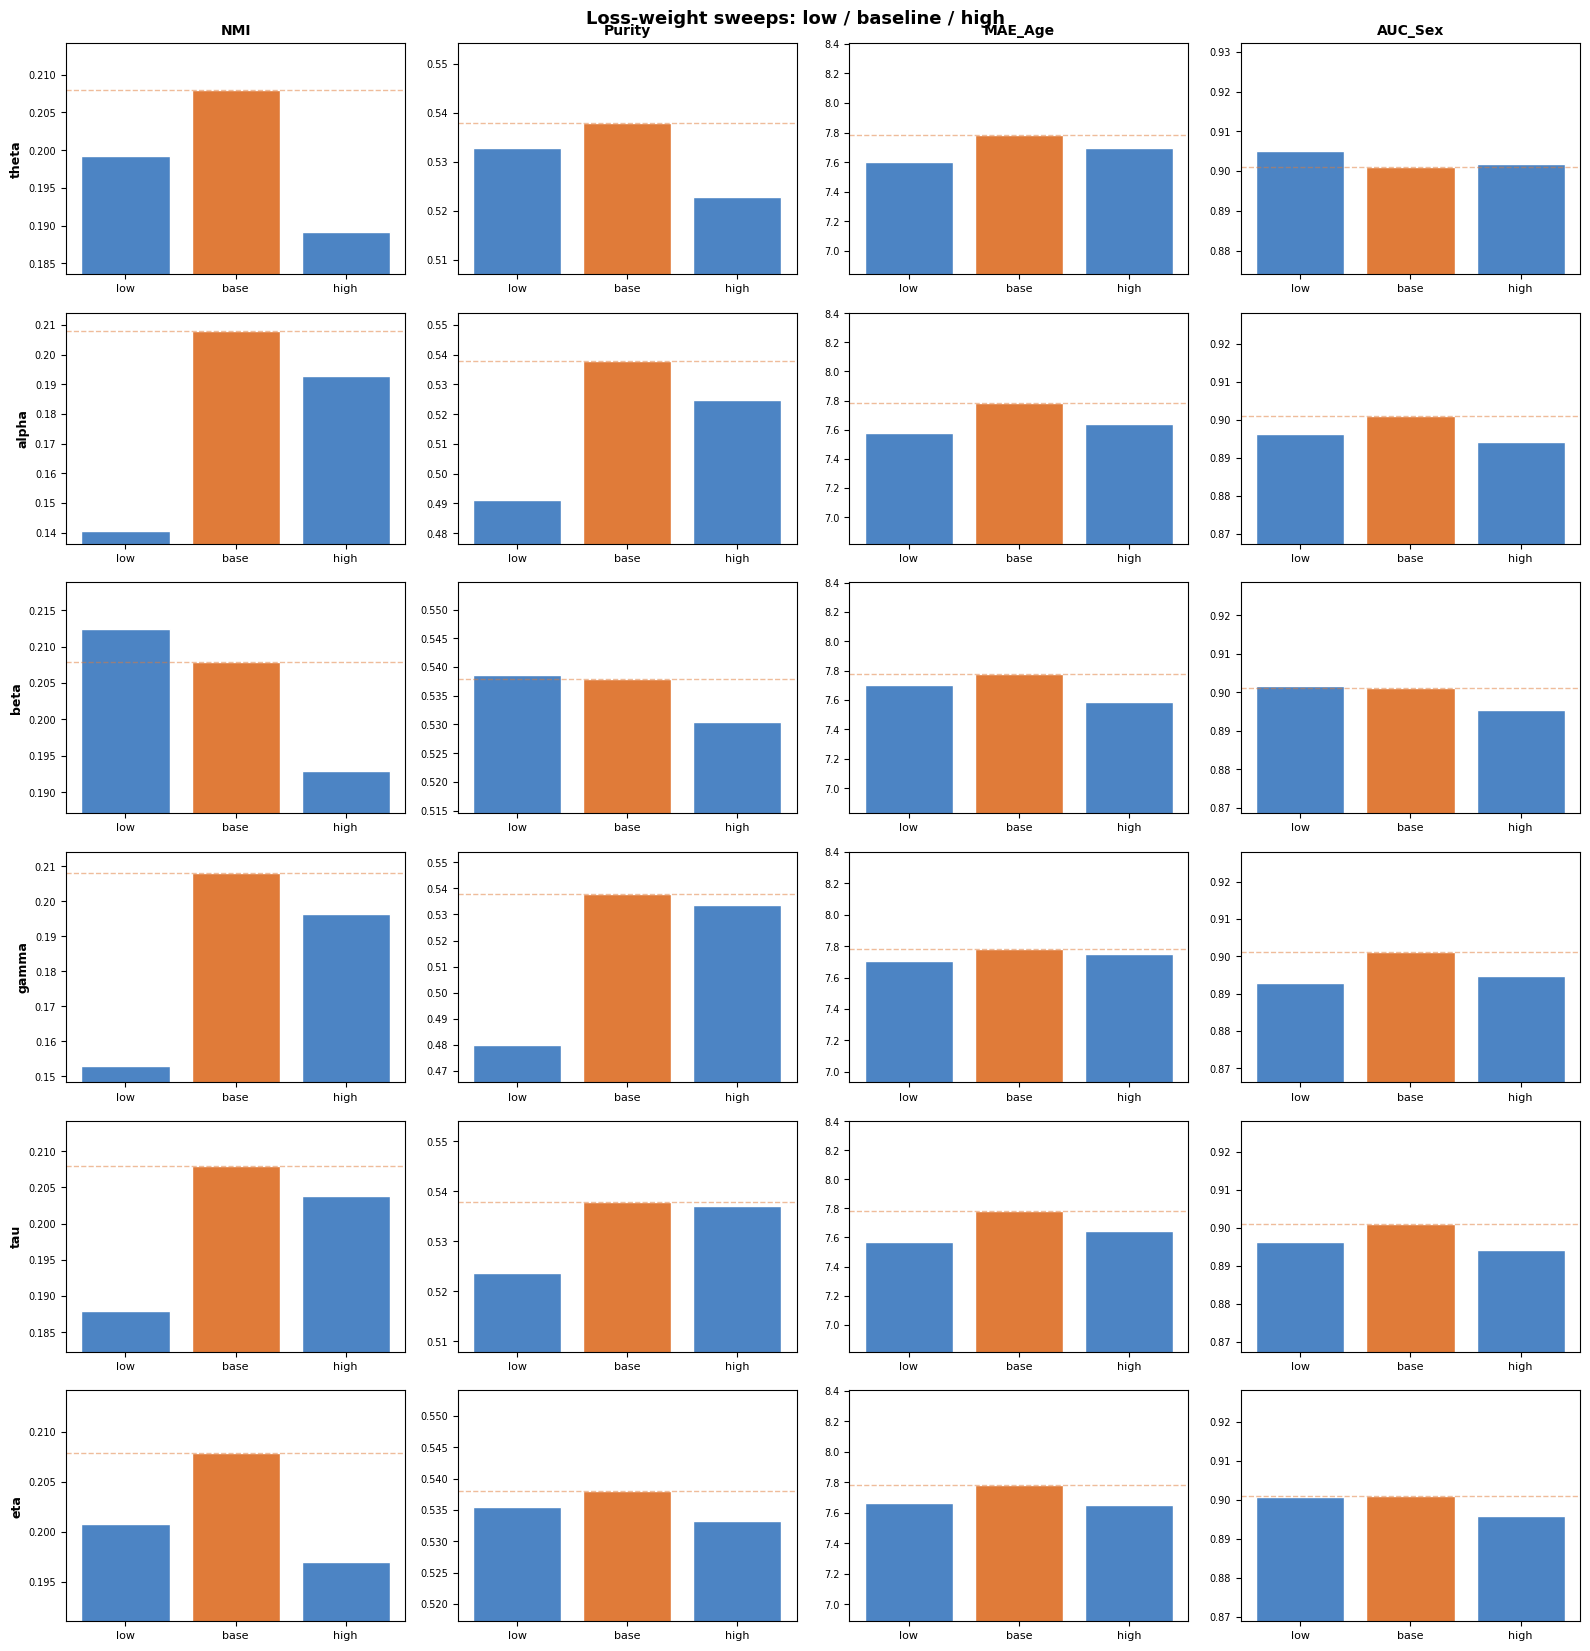

In [5]:
SWEEP_GROUPS = {
    "theta": ("theta_low",  "theta_high"),
    "alpha": ("alpha_low",  "alpha_high"),
    "beta":  ("beta_low",   "beta_high"),
    "gamma": ("gamma_low",  "gamma_high"),
    "tau":   ("tau_low",    "tau_high"),
    "eta":   ("eta_low",    "eta_high"),
}

# build lookup dict: variant → metric values
vdict = df.set_index("variant")[METRICS].to_dict("index")

n_groups = len(SWEEP_GROUPS)
plot_metrics = ["NMI", "Purity", "MAE_Age", "AUC_Sex"]
fig, axes = plt.subplots(n_groups, len(plot_metrics),
                          figsize=(16, 2.8 * n_groups), sharey=False)

for row_idx, (param, (low_var, high_var)) in enumerate(SWEEP_GROUPS.items()):
    for col_idx, metric in enumerate(plot_metrics):
        ax = axes[row_idx][col_idx]
        labels, vals = [], []
        for vname, label_text in [(low_var, "low"), ("baseline", "base"), (high_var, "high")]:
            if vname in vdict:
                labels.append(label_text)
                vals.append(vdict[vname][metric])
        bar_colors = ["#4C84C4", "#E07B39", "#4C84C4"][:len(labels)]
        bars = ax.bar(labels, vals, color=bar_colors, edgecolor="white")
        ax.axhline(vdict.get("baseline", {}).get(metric, np.nan),
                   color="#E07B39", linewidth=1.0, linestyle="--", alpha=0.5)
        if LOWER_IS_BETTER[metric]:
            best_val = min(vals)
            ax.set_ylim(bottom=max(0, min(vals) * 0.9), top=max(vals) * 1.08)
        else:
            ax.set_ylim(bottom=min(vals) * 0.97, top=max(vals) * 1.03)
        if col_idx == 0:
            ax.set_ylabel(param, fontweight="bold", fontsize=9)
        if row_idx == 0:
            ax.set_title(metric, fontweight="bold", fontsize=10)
        ax.tick_params(axis="x", labelsize=8)
        ax.tick_params(axis="y", labelsize=7)

fig.suptitle("Loss-weight sweeps: low / baseline / high", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("ablation_sweeps.png", dpi=150, bbox_inches="tight")
plt.show()

## 5 — Age-correction ablations

Focus on the variants that modify the age-correction module: `no_age_corr`, `more_topk`, `less_topk`, `fast_ramp`, `slow_ramp`.

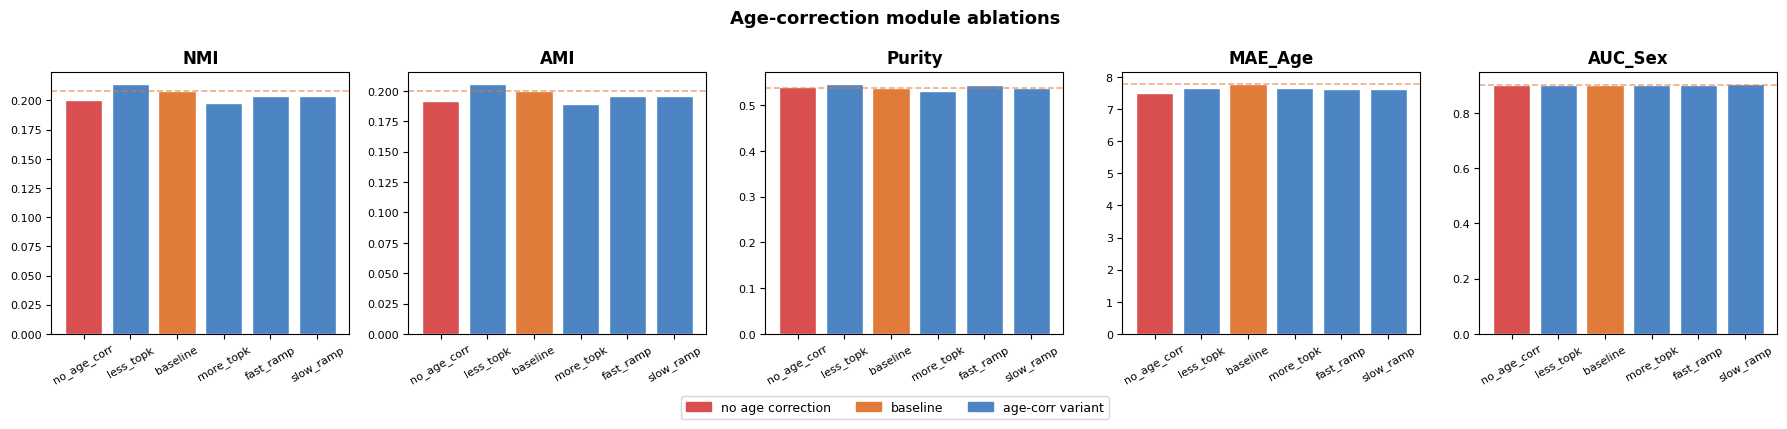

In [6]:
AGE_CORR_VARIANTS = ["no_age_corr", "less_topk", "baseline", "more_topk", "fast_ramp", "slow_ramp"]
age_df = df[df["variant"].isin(AGE_CORR_VARIANTS)].copy()
# preserve order
age_df["_ord"] = age_df["variant"].map({v: i for i, v in enumerate(AGE_CORR_VARIANTS)})
age_df = age_df.sort_values("_ord").reset_index(drop=True)

fig, axes = plt.subplots(1, len(METRICS), figsize=(18, 4), sharey=False)
bar_colors = ["#D94F4F" if v == "no_age_corr" else
              "#E07B39" if v == "baseline" else
              "#4C84C4" for v in age_df["variant"]]

for ax, metric in zip(axes, METRICS):
    bars = ax.bar(age_df["variant"], age_df[metric], color=bar_colors, edgecolor="white")
    ax.set_title(metric, fontweight="bold")
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)
    bval = age_df.loc[age_df["variant"] == "baseline", metric].values
    if len(bval):
        ax.axhline(bval[0], color="#E07B39", linewidth=1.2, linestyle="--", alpha=0.6)

legend_handles = [
    mpatches.Patch(color="#D94F4F", label="no age correction"),
    mpatches.Patch(color="#E07B39", label="baseline"),
    mpatches.Patch(color="#4C84C4", label="age-corr variant"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=3,
           bbox_to_anchor=(0.5, -0.06), fontsize=9)
fig.suptitle("Age-correction module ablations", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("ablation_age_corr.png", dpi=150, bbox_inches="tight")
plt.show()

## 6 — Loss-term ablations

Variants that remove individual loss components: `no_disentangle`, `no_age`, `no_sex`, `no_temporal`, `no_record_attn`, `no_som_commit`.

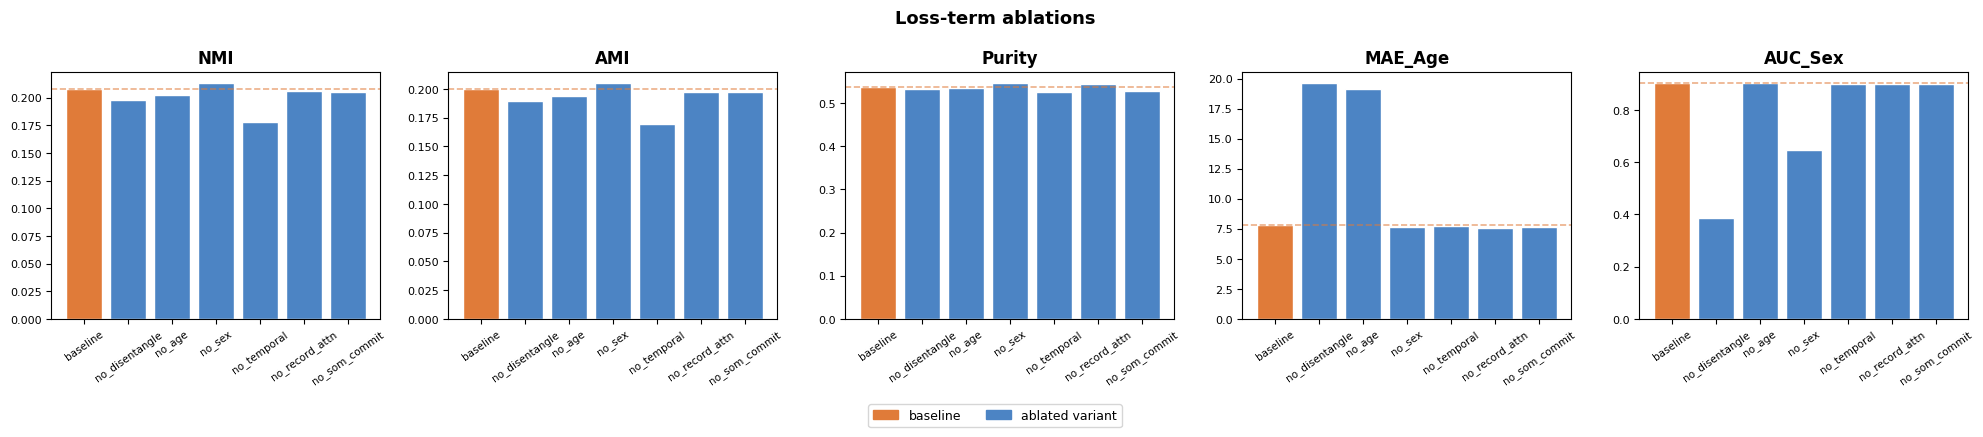

In [7]:
LOSS_VARIANTS = ["baseline", "no_disentangle", "no_age", "no_sex",
                 "no_temporal", "no_record_attn", "no_som_commit"]
loss_df = df[df["variant"].isin(LOSS_VARIANTS)].copy()
loss_df["_ord"] = loss_df["variant"].map({v: i for i, v in enumerate(LOSS_VARIANTS)})
loss_df = loss_df.sort_values("_ord").reset_index(drop=True)

fig, axes = plt.subplots(1, len(METRICS), figsize=(20, 4))
bar_colors_l = ["#E07B39" if v == "baseline" else "#4C84C4" for v in loss_df["variant"]]

for ax, metric in zip(axes, METRICS):
    bars = ax.bar(loss_df["variant"], loss_df[metric], color=bar_colors_l, edgecolor="white")
    ax.set_title(metric, fontweight="bold")
    ax.tick_params(axis="x", rotation=35, labelsize=7.5)
    ax.tick_params(axis="y", labelsize=8)
    bval = loss_df.loc[loss_df["variant"] == "baseline", metric].values
    if len(bval):
        ax.axhline(bval[0], color="#E07B39", linewidth=1.2, linestyle="--", alpha=0.6)

legend_handles = [
    mpatches.Patch(color="#E07B39", label="baseline"),
    mpatches.Patch(color="#4C84C4", label="ablated variant"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=2,
           bbox_to_anchor=(0.5, -0.08), fontsize=9)
fig.suptitle("Loss-term ablations", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("ablation_loss_terms.png", dpi=150, bbox_inches="tight")
plt.show()

## 7 — Radar chart: top-N variants

Visualise the multi-metric profile of the best-performing variants on a radar / spider chart.

/tmp/ipykernel_2036962/2123580693.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_fn = cm.get_cmap("tab10")


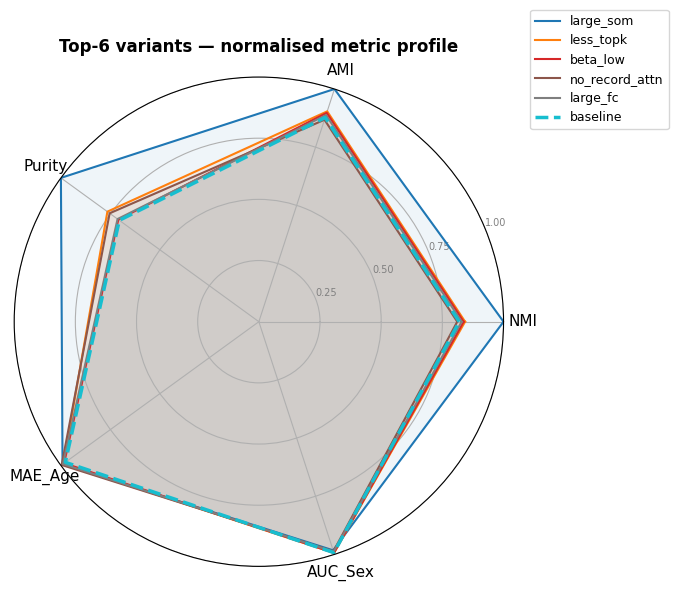

In [8]:
TOP_N = 6   # change this to show more/fewer variants

# re-use the normalised scores from section 3
norm_scores = norm_df.copy()
norm_scores["mean"] = norm_scores.mean(axis=1)
top_variants = norm_scores.sort_values("mean", ascending=False).head(TOP_N).index.tolist()
# ensure baseline is included
if "baseline" not in top_variants:
    top_variants[-1] = "baseline"

radar_metrics = METRICS
N = len(radar_metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
cmap_fn = cm.get_cmap("tab10")
colors = [cmap_fn(i) for i in np.linspace(0, 0.9, len(top_variants))]

for i, variant in enumerate(top_variants):
    vals = [norm_scores.loc[variant, m] for m in radar_metrics]
    vals += vals[:1]
    lw = 2.5 if variant == "baseline" else 1.5
    ls = "--" if variant == "baseline" else "-"
    ax.plot(angles, vals, color=colors[i], linewidth=lw, linestyle=ls, label=variant)
    ax.fill(angles, vals, color=colors[i], alpha=0.07)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], fontsize=7, color="grey")
ax.set_title(f"Top-{TOP_N} variants — normalised metric profile", fontweight="bold",
             pad=18, fontsize=12)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.savefig("ablation_radar.png", dpi=150, bbox_inches="tight")
plt.show()

## 8 — Failures / errored variants

Show which variants failed and a short excerpt of the error message.

In [9]:
df_failed = df_raw[df_raw["NMI"].isna()].copy()
df_failed["short_error"] = df_failed["error"].fillna("").str.split("\n").str[0].str[:120]

print(f"{len(df_failed)} failed variants:\n")
for _, row in df_failed.iterrows():
    print(f"  {row['variant']:<30}  {row['short_error']}")

AttributeError: Can only use .str accessor with string values!